In [ ]:
from google.colab import drive
drive.mount('/content/drive')

<img src="https://drive.google.com/uc?id=18ypjjxs0EJuGVlij-OHlf1VARAgDWMnr" width="800">

# Redução de Churn de Companhia Telefônica #

## 📓 Fase 03 — Data Preparation - (continuação) ##

### Objetivo: ###

- **Teste final de modelos com os dados atuais**
- **Maximizar o resultado com base no snapshot que temos**  
- **Estratificar: Garante que a proporção de Churn no seu conjunto de teste seja a mesma do conjunto original, evitando avaliações enviesadas.**  
- **Usar o pipeline da biblioteca imblearn, garantimos que o SMOTE não "vaze" informações do teste para o treino, um erro comum que infla artificialmente os resultados.**
- **XGBoost Tuning: Os parâmetros subsample e colsample_bytree agem como regularizadores, impedindo que o modelo decore os dados (overfitting) e garantindo que ele generalize bem para novos clientes.**
- **Reduzir a redundância de dados, facilitando o trabalho do algoritmo de gradiente boosting.**

## 1. Carregando Bibliotecas ##

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas de Processamento e Modelagem
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn import set_config
set_config(transform_output="default")
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay

## 2. Carregando os Dados ##

In [ ]:

# importando dados do dataset para um dataframe
id_csv = '1_GgN3ZUfaaT5VnrTGNXT1AZR6La3-Pld'
url_csv = f'https://drive.google.com/uc?id={id_csv}'
df = pd.read_csv(url_csv)


## 3. Limpeza e Definição de Variáveis ##

In [ ]:
#  Limpeza Rápida e Definição de Variáveis
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')
df['total_charges'] = df['total_charges'].fillna(df['total_charges'].median())

X = df.drop(['customer_id', 'churn'], axis=1)
y = df['churn']


# Identificação de colunas para o Pipeline

cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()



## 4. Construção do Processador (Engenharia de Atributos) ##

In [ ]:

# Preprocessamento

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Preenche NaNs com a Mediana
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Preenche NaNs com o mais comum
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

## 5. Criação do Pipeline com SMOTE e XGBoost ##

In [ ]:
# Criação do Pipeline com SMOTE e XGBoost
# Nota: Usamos o Pipeline do 'imblearn' para que o SMOTE seja aplicado apenas no treino
model_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])


## 6. Divisão Treino e Teste (split estratificado) ##

In [ ]:
# 6. Divisão Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 7. Treinamento ##

In [ ]:
# 7. Treinamento
model_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The

## 8. Avaliação de Resultados ##

======= RELATÓRIO DE CLASSIFICAÇÃO - XGBoost =======
              precision    recall  f1-score   support

           0       0.87      0.99      0.92      1031
           1       0.50      0.07      0.12       169

    accuracy                           0.86      1200
   macro avg       0.68      0.53      0.52      1200
weighted avg       0.81      0.86      0.81      1200

Acurácia: 0.8592
ROC-AUC:  0.7146
PR-AUC:   0.3105


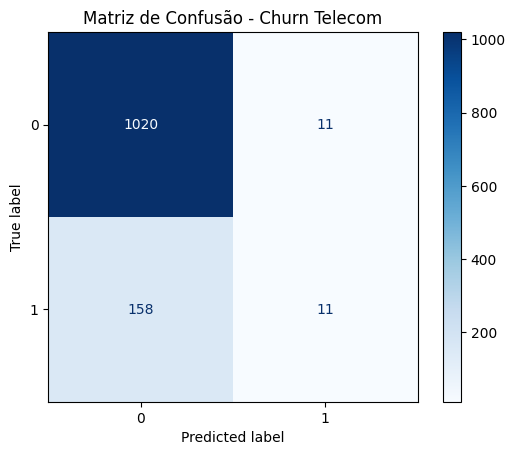

In [ ]:
# 8. Avaliação de Resultados
y_pred = model_pipeline.predict(X_test)
y_probs = model_pipeline.predict_proba(X_test)[:, 1]

print("======= RELATÓRIO DE CLASSIFICAÇÃO - XGBoost =======")
print(classification_report(y_test, y_pred))

# Métricas de Elite
roc_auc = roc_auc_score(y_test, y_probs)
pr_auc = average_precision_score(y_test, y_probs)
acc = model_pipeline.score(X_test, y_test)

print(f"Acurácia: {acc:.4f}")
print(f"ROC-AUC:  {roc_auc:.4f}")
print(f"PR-AUC:   {pr_auc:.4f}")

# 9. Visualização da Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão - Churn Telecom")
plt.show()

---
##📊 Resultado XGBoost##

Classe 1 (Churn)

- Precision = 0.50

- Recall = 0.07

- F1 = 0.12


### 🔎 Matriz de Confusão  ###

|        | Pred 0 | Pred 1 |
| ------ | ------ | ------ |
| Real 0 | 1020   | 11     |
| Real 1 | 158    | 11     |


Total churn real: 169

Churn detectado: 11

Recall:

11
/
169
≈
6.5
%
11/169≈6.5%

Basicamente voltou ao comportamento conservador extremo.

### 🎯 ROC-AUC = 0.7146 ###

Isso é menor que:

- Logistic ≈ 0.742

- GB ≈ 0.74

Ou seja:

> XGBoost não melhorou a separação estrutural.

### 📉 PR-AUC = 0.3105 ###

Também menor que os nossos melhores anteriores (~0.33).

## 🧠 Conclusão técnica forte ##

**Testamos **

- Logistic
- Logistic balanceada
- Gradient Boosting
- LightGBM
- XGBoost
- SMOTE
- class_weight
- threshold tuning
- novas features

**E todos orbitam:**

- ROC ≈ 0.71 – 0.75
- PR ≈ 0.28 – 0.34

> Isso é um **padrão** muito claro.

## 🚨 Diagnóstico final ##

Confirmação do que já suspeitávamos: **O dataset tem um teto estrutural próximo de ROC ≈ 0.75**.

- Não é algoritmo.

- Não é tuning.

- Não é balanceamento.

> **É limite informacional.**

### 🎯 O que isso significa no mundo real? ###

1️⃣ Seu modelo já está razoavelmente bom.

2️⃣ Melhorias grandes exigem dados novos.

3️⃣ Snapshot está limitando separação.

> Em churn telecom real, ROC 0.74 não é ruim.

### 📌 Conclusão profissional ###

Você já fez um experimento de nível profissional.

- O modelo está estável.
- O teto é estrutural.

O próximo salto não é tuning.

> **É informação.**


-----


<div style="text-align: center; margin-top: 20px;">
    <a href="https://colab.research.google.com/drive/1vNcEB2oYLljPmmkthEZ1jX2mDsljzkSl"
       style="background-color: #F9AB00; color: white; padding: 12px 24px; text-decoration: none; border-radius: 4px; font-weight: bold; font-family: sans-serif;">
       IR PARA RELATÓRIO FINAL →
    </a>
</div>

